# Ecommerce Customers - Linear Regression

In this project, we apply Linear Regression on a new dataset to predict customer yearly spending.


## Import Libraries

We start by importing the required libraries.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

We load the Ecommerce Customers dataset.


In [5]:
df = pd.read_csv('Ecommerce Customers')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## Data Exploration

We explore the dataset structure and statistics.

In [6]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

## Data Cleaning

We remove non-numeric columns that are not useful for the model.

In [7]:
df = df.drop(['Email', 'Address', 'Avatar'], axis=1)

## Exploratory Data Analysis

We visualize relationships between features.

<Axes: >

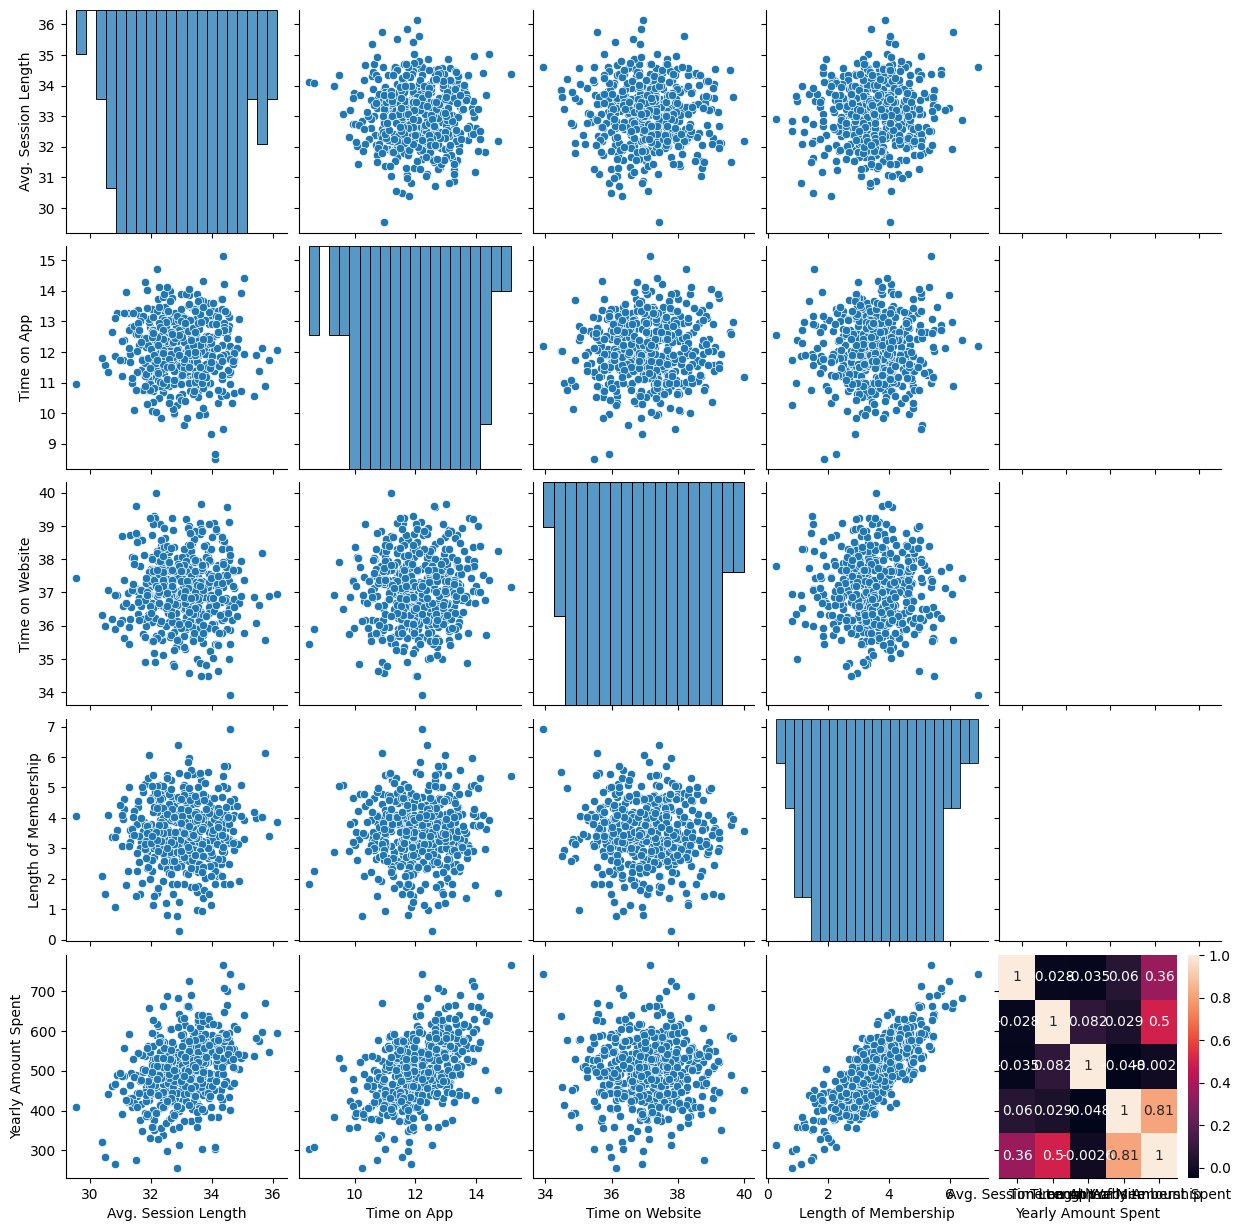

In [8]:
sns.pairplot(df)
sns.heatmap(df.corr(), annot=True)

## Preparing Data

We define the features (X) and the target variable (y).

In [10]:
X = df.drop('Yearly Amount Spent', axis=1)
y = df['Yearly Amount Spent']

## Train-Test Split

We split the data into training and testing sets.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

## Training the Model

We train a Linear Regression model.

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Predictions

We make predictions using the test data.

In [13]:
predictions = model.predict(X_test)

## Model Evaluation

We evaluate the model using MAE, MSE, and RMSE.

In [14]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.74267128583874
MSE: 93.83297800820075
RMSE: 9.68674238370159


## Visualization

We compare actual vs predicted values.

Text(0, 0.5, 'Predicted')

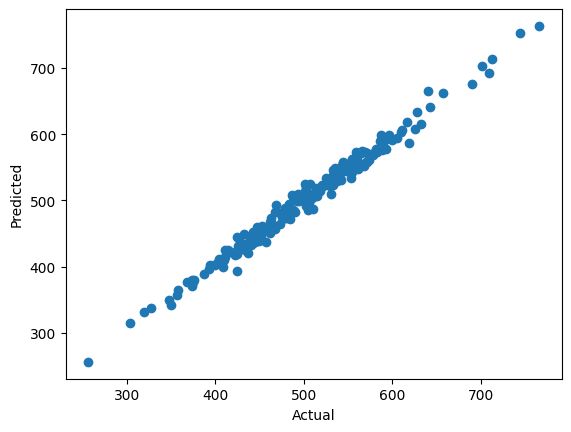

In [15]:
plt.scatter(y_test, predictions)
plt.xlabel('Actual')
plt.ylabel('Predicted')

## Residuals

We check the distribution of errors.

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

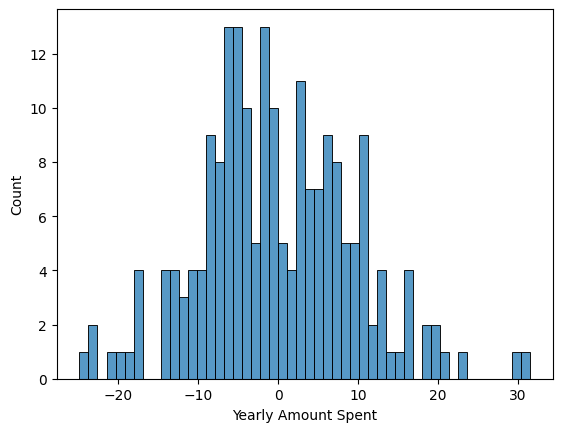

In [16]:
sns.histplot((y_test - predictions), bins=50)

## Conclusion

The Linear Regression model was able to predict customer yearly spending with reasonable accuracy based on the given features.
